# quantem.data - share datasets through Hugging Face
Pull and publish reference 4D-STEM / HAADF datasets with one line, no `huggingface_hub` code. The repo is **public**: `list` / `status` / `meta` / `download` need **no token**. Only `upload` needs one.

## Install
```bash
pip install -i https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple/ quantem.data
```

## What's available
CLI or Python. The CLI `list` is the **remote** list (what's on Hugging Face):
```bash
quantem-data list
quantem-data status
```

In [1]:
from quantem.data import hub

names = hub.list_datasets()   # remote dataset names
names[:8]

['4dstem/gold_30mrad1.3mx04',
 '4dstem/gold_30mrad1.3mx06',
 '4dstem/gold_30mrad1.3mx07',
 '4dstem/gold_30mrad1.3mx09',
 '4dstem/gold_512',
 '4dstem/gold_512_npy_bin4',
 '4dstem/gold_512_npy_bin8',
 'haadf/gold_drift_0deg']

In [2]:
# repo summary: each dataset's file count and size (status() returns a dict; the list is under 'datasets')
s = hub.status()
print(s['repo'], '-', f"{s['total_mb']:.0f} MB total")
for d in s['datasets']:
    print(f"{d['size_mb']:>9.1f} MB  {d['files']:>3} files  {d['name']}")

bobleesj/quantem-data - 30903 MB total
   3157.9 MB   39 files  4dstem/gold_30mrad1.3mx04
   7081.7 MB   40 files  4dstem/gold_30mrad1.3mx06
   7120.0 MB   40 files  4dstem/gold_30mrad1.3mx07
   7045.0 MB   40 files  4dstem/gold_30mrad1.3mx09
   4889.1 MB   29 files  4dstem/gold_512
   1208.0 MB    2 files  4dstem/gold_512_npy_bin4
    302.0 MB    2 files  4dstem/gold_512_npy_bin8
      8.7 MB    1 files  haadf/gold_drift_0deg
      8.7 MB    1 files  haadf/gold_drift_90deg
     33.8 MB    1 files  haadf/gold_haadf
     33.6 MB    2 files  haadf/gold_haadf_npy
      0.0 MB    1 files  notebooks/show4dstem_colab
     14.1 MB    1 files  notebooks/widget_4dstem_demo


## Read a dataset's metadata
`read_meta` returns the calibration sidecar (scan sampling, FOV, voltage, ...), or `None` if it has none.

In [3]:
hub.read_meta('gold_512_npy_bin4')

{'name': 'gold_512_npy_bin4',
 'shape': [512, 512, 48, 48],
 'dtype': 'uint16',
 'sampling': [0.5, 0.5, 1.84, 1.84],
 'units': ['A', 'A', 'mrad', 'mrad'],
 'bin_factor': {'scan': 1, 'det': 4},
 'original_shape': [512, 512, 192, 192],
 'original_sampling': [0.5, 0.5, 0.46, 0.46],
 'source': 'Arina 4D-STEM master /home/owner/ssd/data/bob/20260423_gold_drift_v6_4dstem_pair/gold_004_master.h5 (drift-pair acquisition; sibling session 20260408_gold_4dstem_512_ssb/dataset.yaml supplies optics)',
 'purpose': 'workshop / Colab demo - full real-space, detector-only bin',
 'voltage_kV': 300,
 'camera_length_mm': 91,
 'probe_semiangle_mrad': 30,
 'mag_MX': None,
 'rotation_deg': 0.0,
 'voltage_kV_source': 'confirmed via session HAADF EMD (20260423/0072-*.emd, AccelerationVoltage)',
 'probe_semiangle_source': 'confirmed via session HAADF EMD (BeamConvergence 0.02999 rad)',
 'camera_length_source': 'confirmed via session HAADF EMD (CameraLength 0.091 m)',
 'scan_sampling_A_source': 'operator pattern

## Download a dataset
Name it by its flat name; `download` finds its bucket and fetches it. Start with a small one.

In [4]:
path = hub.download('gold_drift_0deg')   # ~9 MB HAADF
print(path)

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

'gold_drift_0deg' (0.01 GB) is already cached on disk - no re-download.
  cached at: /home/owner/.cache/huggingface/hub/datasets--bobleesj--quantem-data/snapshots/228f4d4e5ff4bed413842a1d26a9d210e34dbf7c/haadf/gold_drift_0deg.emd


/home/owner/.cache/huggingface/hub/datasets--bobleesj--quantem-data/snapshots/228f4d4e5ff4bed413842a1d26a9d210e34dbf7c/haadf/gold_drift_0deg.emd


## Load what you downloaded
Use `quantem.widget.io` to read it into a `Dataset2d`; the pixels are on `.array`:

(2048, 2048) uint16 282 10502


(<Figure size 400x400 with 1 Axes>,
 <Axes: title={'center': 'gold_drift_0deg'}>)

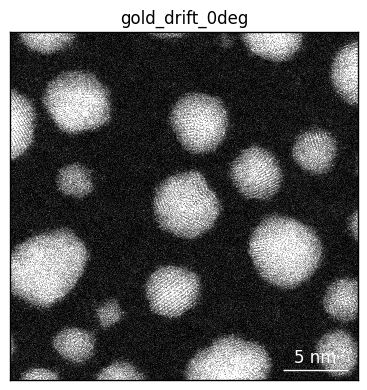

In [5]:
from quantem.widget import io
ds = io.read_image(path)            # Dataset2d
arr = ds.array                     # the numpy array (note: .array, not .data)
print(arr.shape, arr.dtype, arr.min(), arr.max())
ds.show()

## Publish a dataset (owner only - needs an HF write token)
`upload` writes, so log in first (`huggingface-cli login` or set `HF_TOKEN`). Attach a sidecar with `meta=`. Not run here (it mutates the repo):
```python
hub.upload('my_scan.h5', name='gold_run42', folder='4dstem',
           meta={'voltage_kV': 300, 'scan_sampling_A': 0.2})
```
Or: `quantem-data upload my_scan.h5 --folder 4dstem --name gold_run42 --meta cal.json`